In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [3]:
from true_graph import TrueGraph
from learner import FactorGraphLearner, learner_to_graph
from noise_generator import IndependentMarginals
from metrics import *
from random_graph import generate_random_graph, generate_random_tree
from chow_liu import chow_liu

# Trees (Varying Graph Size)

In [4]:
TREE_SIZES = np.arange(5,51,5, dtype=np.int32)

In [5]:
tree_list = []
sample_list = []

N = 1000

for n in tqdm(TREE_SIZES):
    rng = np.random.default_rng(seed=165)
    g = generate_random_tree(n, 2, rng)
    samps = g.sample(N, seed=650, progress=False)
    tree_list.append(g)
    sample_list.append(samps)

100%|███████████████████████████████████████████| 10/10 [01:14<00:00,  7.44s/it]


# Graphs (Varying Graph Density)

In [6]:
N_VARIABLE = 12
NUM_FACTORS = list(range(4,13))

N = 1000

graph_list = []
graph_sample_list = []

for nf in tqdm(NUM_FACTORS):
    rng = np.random.default_rng(seed=882)
    g = generate_random_graph(N_VARIABLE, 2, rng, n_factors=nf)
    samps = g.sample(N, seed=648, progress=False)
    graph_list.append(g)
    graph_sample_list.append(samps)

100%|█████████████████████████████████████████████| 9/9 [00:28<00:00,  3.20s/it]


# Sample Sizes (Varying Sample Size)

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Factor Graph'}>)

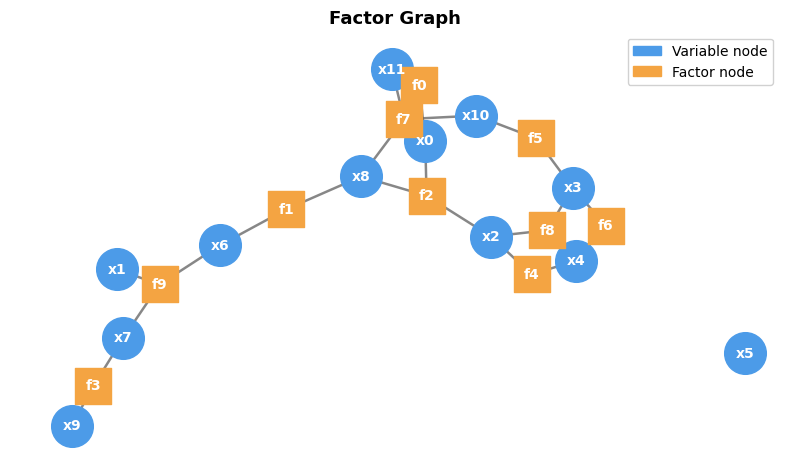

In [7]:
rng = np.random.default_rng(seed=688)
ss_graph = generate_random_graph(n=12, alphabet_size=2, rng=rng, n_factors=10)
ss_graph.display_graph(seed=1)

In [8]:
samples_list = []

all_samples = ss_graph.sample(10000, seed=390, progress=True)
for nsamp in [100,200,500,1000,2000,5000,10000]:
    samps = all_samples[:nsamp]
    samples_list.append(samps)

100%|████████████████████████████████████| 10000/10000 [00:31<00:00, 316.75it/s]


In [9]:
s_graph_list = [ss_graph for _ in samples_list]

# Learn

In [10]:
def run_learners(graph_list, sample_list, n_runs=5,
                 epochs=100, lr=0.01, seed=123,
                 lambda_bp=1e-3, lambda_mask=0.0, lambda_weight=0.0, lambda_mlp=1e-2, schedule=True):
    results = []
    lrn_seeds = np.random.default_rng(seed).integers(0,10000,size=n_runs)
    for i in tqdm(range(len(graph_list))):
        graph = graph_list[i]
        samples = sample_list[i]
        n_vars = graph.n
        log_lambda_here = (np.log10(lambda_bp) + 2.074) - 0.77 * np.log10(samples.shape[0])
        lambda_here = 10**log_lambda_here
        if n_vars <= 15:
            lambda_here = lambda_here
        elif n_vars >= 40:
            lambda_here = lambda_here * 5
        else:
            lambda_here = lambda_here * 2
        alph_size = graph.alphabet_sizes[0]
        n_factors = len(graph.factors)
        n_poss = alph_size**n_vars
        res = {x : [] for x in ["lrn", "KL", "SHD", "density"]}
        for j in range(n_runs):
            ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=714)
            lrn = FactorGraphLearner(
                n_vars=n_vars,
                alphabet_size=alph_size,
                K=n_vars,
                noise_generator=ng,
                hidden_dims=(16,16),
                max_factor_size=5,
                shared_mlp=False,
                seed=lrn_seeds[j]
            )
            lrn.train(
                samples,
                n_epochs=epochs,
                lr=lr,
                lambda_mask=lambda_mask,
                lambda_weight=lambda_weight,
                lambda_mlp_l2=lambda_mlp,
                lambda_bp=lambda_here,
                penalty_schedule=schedule,
                verbose=False
            )
            res["lrn"].append(lrn)
            if n_poss <= 100000:
                res["KL"].append(kl_divergence(graph, lrn))
            res["SHD"].append(structural_hamming_distance(graph, lrn))
            res["density"].append(graph_density(lrn))
        chow_liu_res = chow_liu(samples, alph_size)
        results.append({
            'learners' : res["lrn"],
            'Chow-Liu Graph' : chow_liu_res,
            'True Graph' : graph,
            'n_samples' : samples.shape[0],
            'n_variables' : n_vars,
            'n_factors' : n_factors,
            'KL' : {'mean' : np.mean(res["KL"]), 'sd' : np.std(res["KL"])} if n_poss <= 100000 else {'mean' : None, 'sd' : None},
            'KL Chow-Liu' : kl_divergence(graph, chow_liu_res) if n_poss <= 100000 else None,
            'KL MLE' : kl_mle_optimal(graph, samples) if n_poss <= 100000 else None,
            'SHD' : {'mean' : np.mean(res["SHD"]), 'sd' : np.std(res["SHD"])},
            'SHD Chow-Liu' : structural_hamming_distance(graph, chow_liu_res),
            'true density' : graph_density(graph),
            'density' : {'mean' : np.mean(res["density"]), 'sd' : np.std(res["density"])}
        })
    return results

In [11]:
results_trees = run_learners(tree_list, sample_list, lambda_bp=1e-3)

100%|███████████████████████████████████████████| 10/10 [12:08<00:00, 72.83s/it]


In [12]:
results_graphs = run_learners(graph_list, graph_sample_list, lambda_bp=1e-3)

100%|█████████████████████████████████████████████| 9/9 [05:14<00:00, 34.98s/it]


In [13]:
results_samples = run_learners(s_graph_list, samples_list, lambda_bp=1e-3)

100%|█████████████████████████████████████████████| 7/7 [10:38<00:00, 91.18s/it]


# Visuals

In [14]:
def plot_results(results, x, y):
    xs = [r[x] for r in results]
    if isinstance(results[0][y], dict):
        ys = [r[y]['mean'] for r in results]
        yerr = [r[y]['sd'] for r in results]
        plt.errorbar(xs, ys, yerr=yerr, fmt='o', capsize=3)
    else:
        ys = [r[y] for r in results]
        plt.scatter(xs, ys)
        plt.plot(xs, ys)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

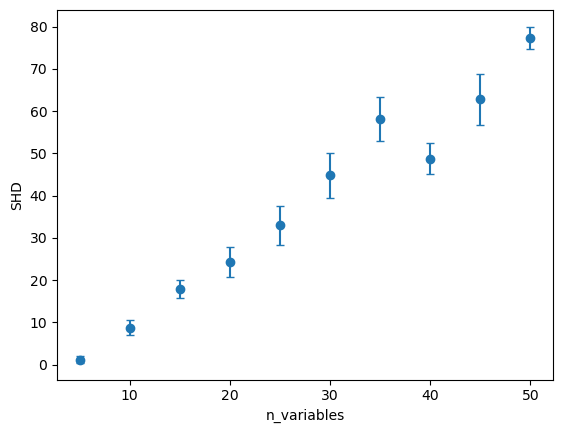

In [15]:
plot_results(results_trees, 'n_variables', 'SHD')

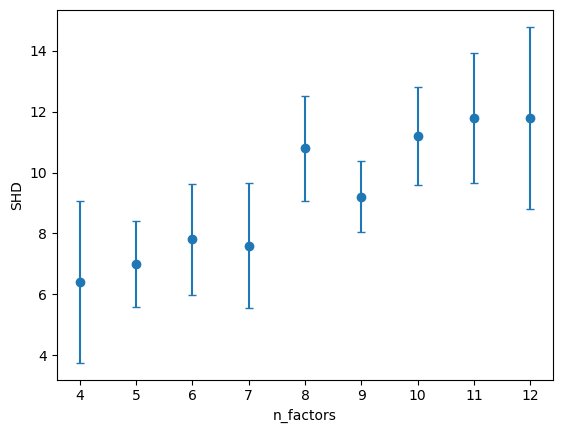

In [16]:
plot_results(results_graphs, 'n_factors', 'SHD')

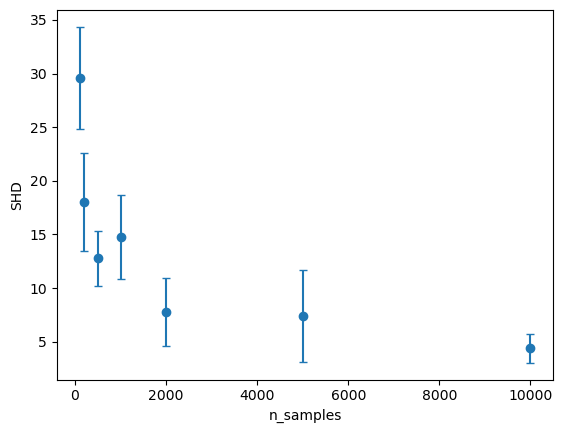

In [17]:
plot_results(results_samples, 'n_samples', 'SHD')

# Recovered Graphs

In [18]:
def learner_to_graph(lrn):
    fscopes = lrn.extract_graph()['factor_scopes']
    def h(): return 1
    factors = [(f, h) for f in fscopes.values()]
    g = TrueGraph(n=lrn.network.n_vars, factors=factors)
    return g

In [19]:
def show_graphs(result, index=0, seed_true=1, seed_lrn=1, seed_cl=1, size=6, savefig=False, path=""):
    true_graph = result['True Graph']
    lrn = result['learners'][index]
    cl = result['Chow-Liu Graph']
    
    fig, axs = plt.subplots(1,3, figsize=(3*size,size))

    true_graph.display_graph(seed=seed_true, ax=axs[0])
    learner_to_graph(lrn).display_graph(seed=seed_lrn, ax=axs[1])
    cl.display_graph(seed=seed_cl, ax=axs[2])
    
    axs[0].set_title("True Graph")
    axs[1].set_title("Network Learned Graph")
    axs[2].set_title("Chow-Liu Graph")

    if savefig:
        plt.savefig(path)
    
    plt.show()

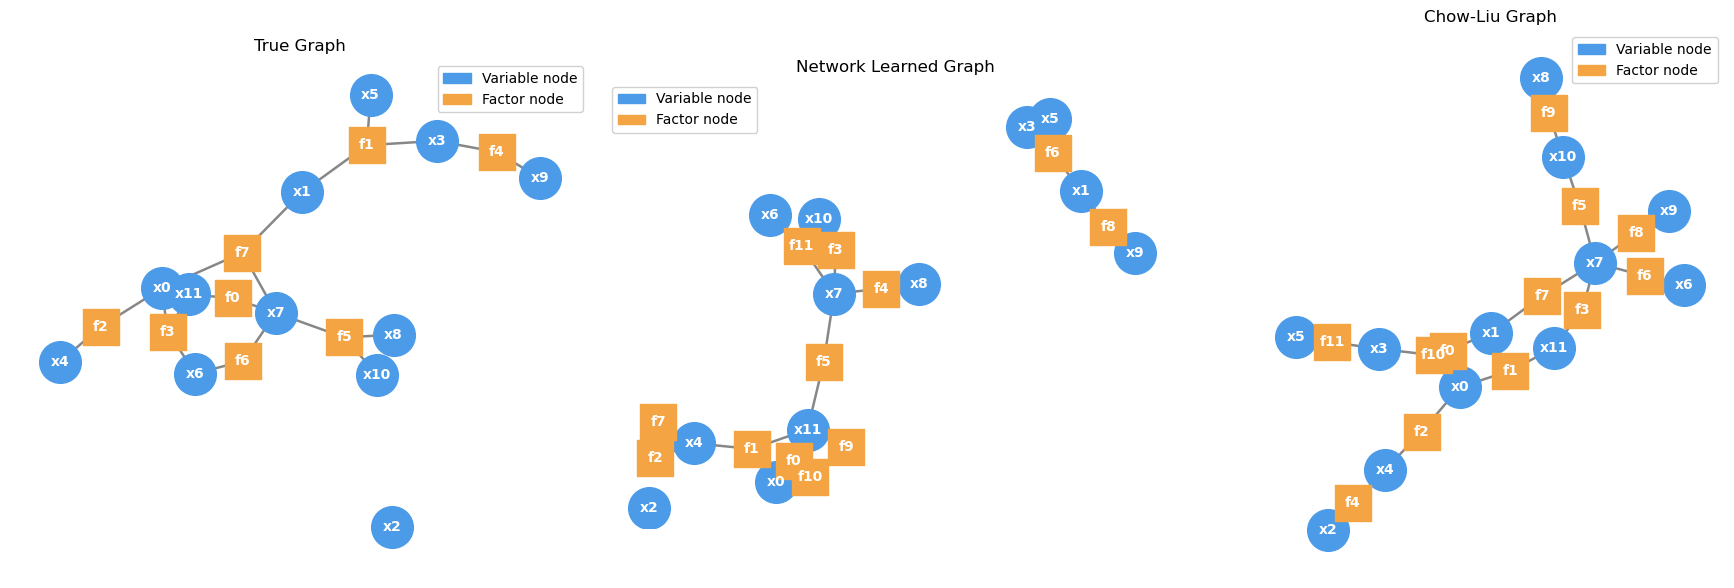

{'learners': [<learner.FactorGraphLearner at 0x169a75050>,
 'Chow-Liu Graph': <true_graph.TrueGraph at 0x169b8f6d0>,
 'True Graph': <true_graph.TrueGraph at 0x13e5a14d0>,
 'n_samples': 1000,
 'n_variables': 12,
 'n_factors': 7,
 'KL': {'mean': 0.06542952334059898, 'sd': 0.026542109053083286},
 'KL Chow-Liu': 0.1271415224458512,
 'KL MLE': 0.5353366212102951,
 'SHD': {'mean': 7.6, 'sd': 2.0591260281974},
 'SHD Chow-Liu': 8,
 'true density': 1.1818181818181819,
 'density': {'mean': 1.3636363636363638, 'sd': 0.12856486930664499}}

In [20]:
show_graphs(results_graphs[4], index=0, seed_true=2, seed_lrn=2, seed_cl=9)
results_graphs[3]

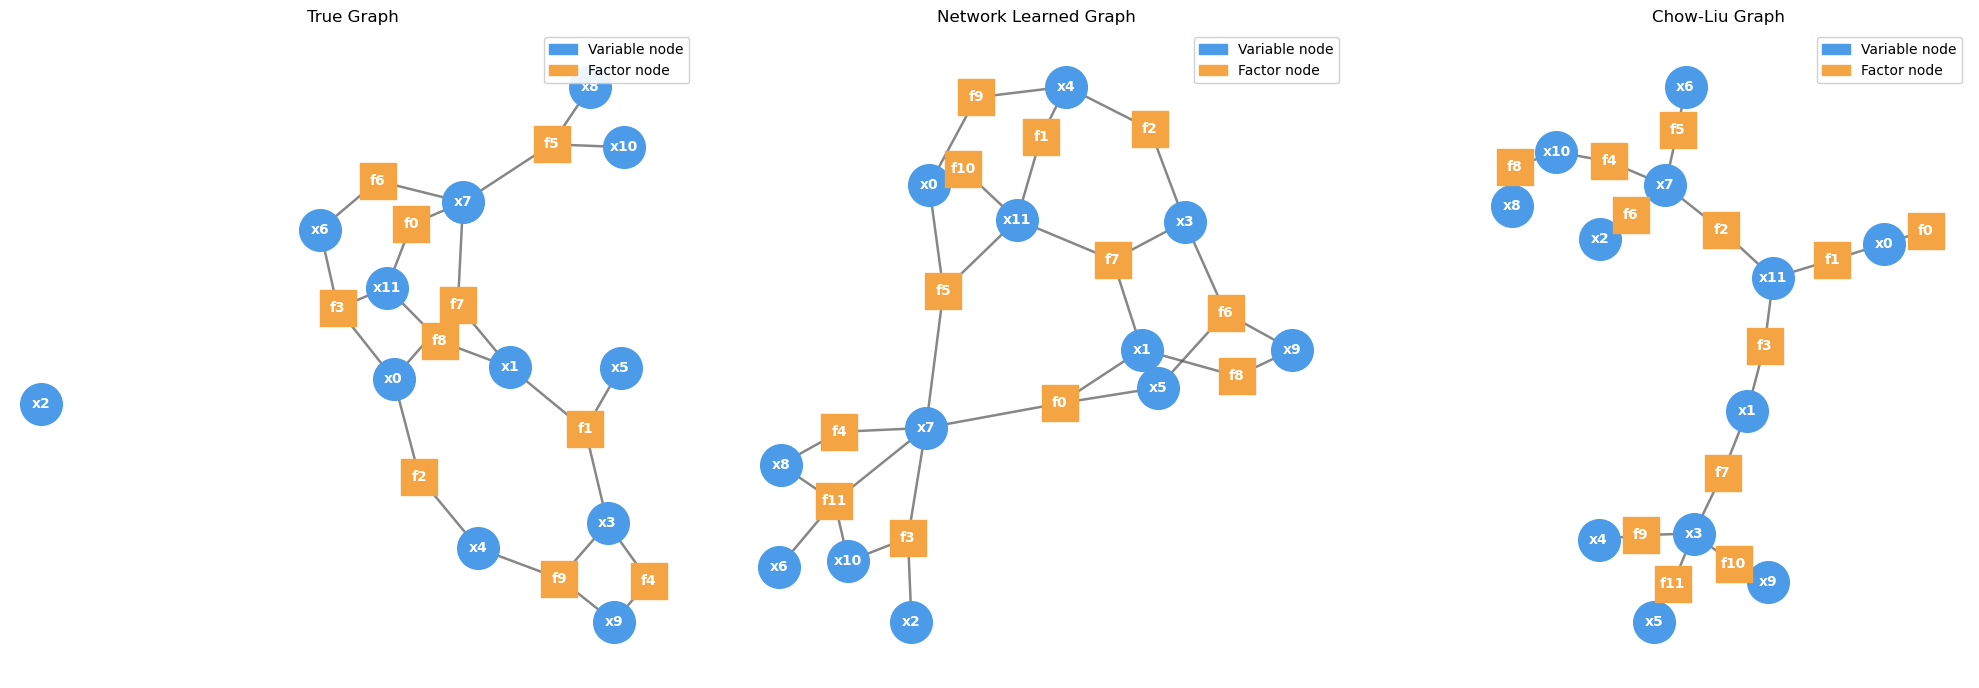

{'learners': [<learner.FactorGraphLearner at 0x1698c3a90>,
 'Chow-Liu Graph': <true_graph.TrueGraph at 0x169e7b550>,
 'True Graph': <true_graph.TrueGraph at 0x13e5c09d0>,
 'n_samples': 1000,
 'n_variables': 12,
 'n_factors': 10,
 'KL': {'mean': 0.18899819965134174, 'sd': 0.09437825242084742},
 'KL Chow-Liu': 0.20339910776772593,
 'KL MLE': 0.4969564074846848,
 'SHD': {'mean': 11.2, 'sd': 1.6},
 'SHD Chow-Liu': 10,
 'true density': 1.7272727272727273,
 'density': {'mean': 1.8, 'sd': 0.24663018120455513}}

In [21]:
show_graphs(results_graphs[6], seed_true=2, seed_lrn=16, seed_cl=6, size=7)
results_graphs[6]

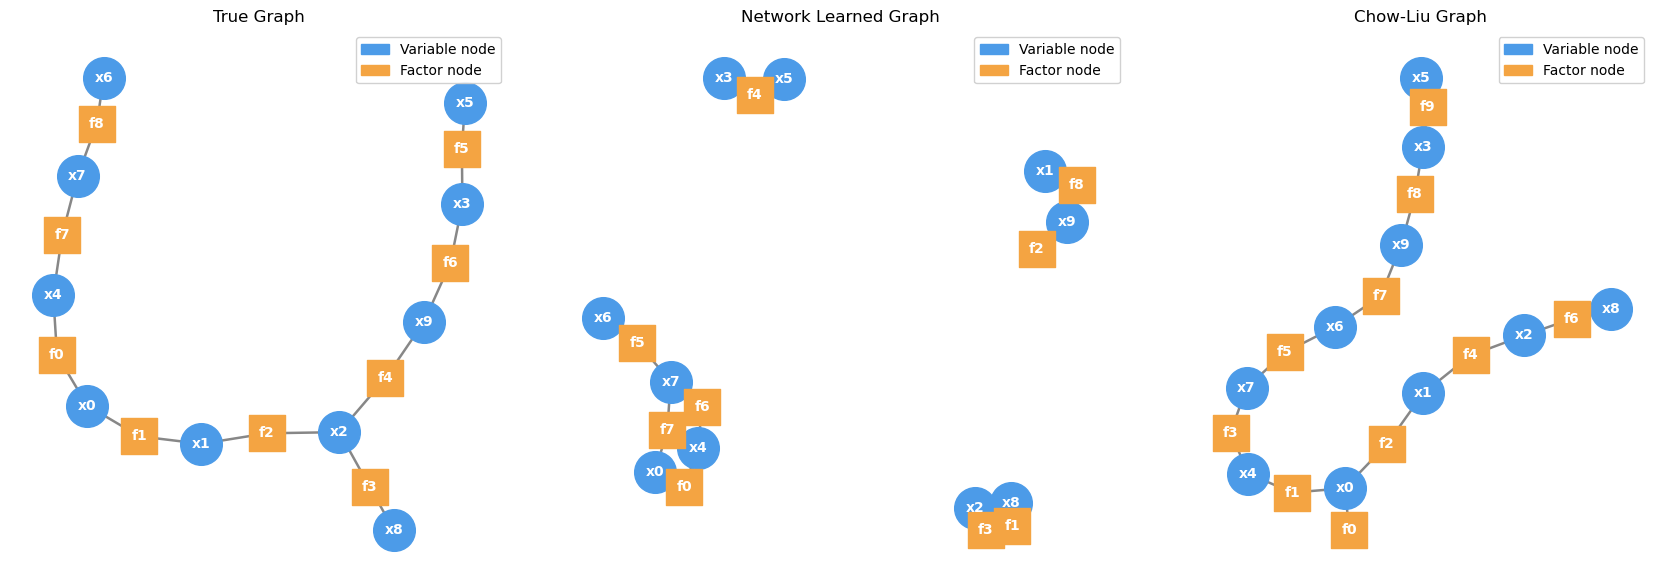

{'learners': [<learner.FactorGraphLearner at 0x14b7d9f90>,
 'Chow-Liu Graph': <true_graph.TrueGraph at 0x14e35e410>,
 'True Graph': <true_graph.TrueGraph at 0x13e58a390>,
 'n_samples': 1000,
 'n_variables': 10,
 'n_factors': 9,
 'KL': {'mean': 0.06074044736474178, 'sd': 0.046915589144009825},
 'KL Chow-Liu': 0.006851244537581646,
 'KL MLE': 0.26753781593845116,
 'SHD': {'mean': 8.8, 'sd': 1.7204650534085253},
 'SHD Chow-Liu': 2,
 'true density': 1.0,
 'density': {'mean': 1.2666666666666666, 'sd': 0.28631330503833613}}

In [22]:
show_graphs(results_trees[1], seed_true=2, seed_lrn=2, seed_cl=2)
results_trees[1]

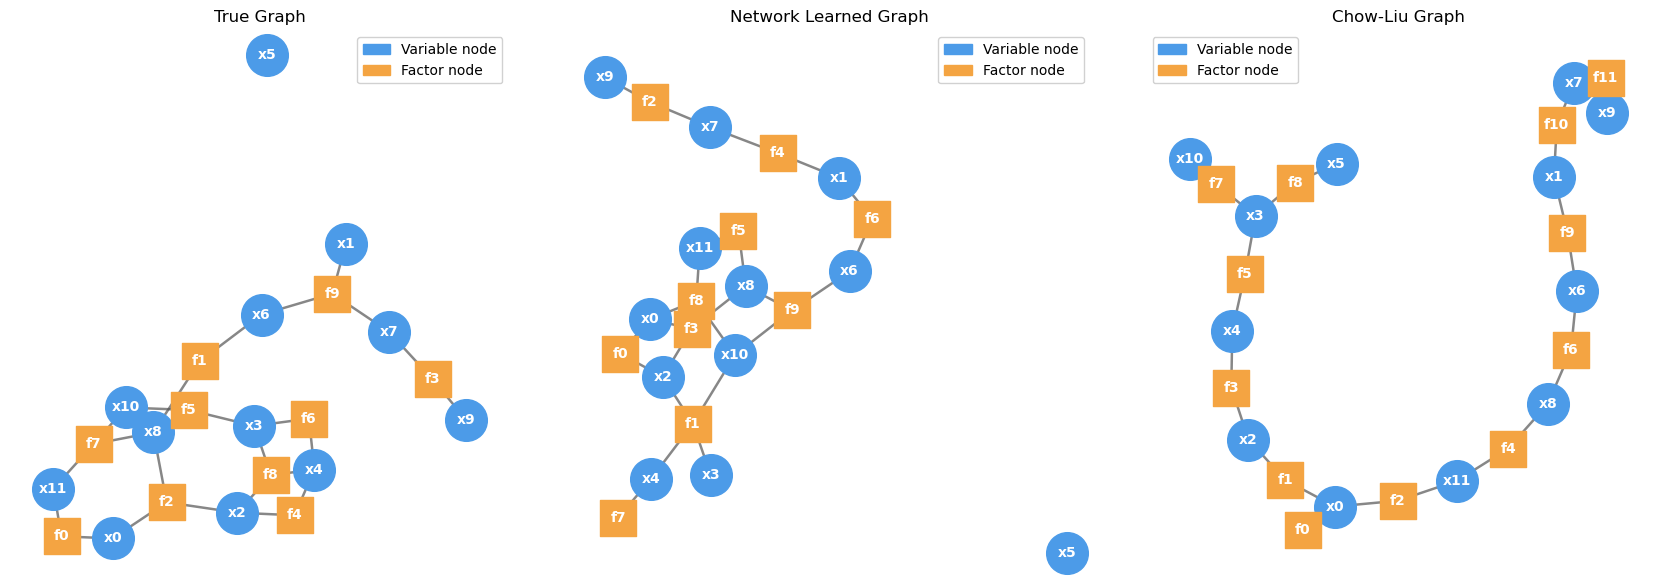

{'learners': [<learner.FactorGraphLearner at 0x16a084b50>,
 'Chow-Liu Graph': <true_graph.TrueGraph at 0x16a712950>,
 'True Graph': <true_graph.TrueGraph at 0x13e591610>,
 'n_samples': 10000,
 'n_variables': 12,
 'n_factors': 10,
 'KL': {'mean': 0.06350962020574515, 'sd': 0.055165427093841715},
 'KL Chow-Liu': 0.10684940765093898,
 'KL MLE': 0.12331904691887144,
 'SHD': {'mean': 4.4, 'sd': 1.3564659966250536},
 'SHD Chow-Liu': 7,
 'true density': 1.4545454545454546,
 'density': {'mean': 1.4545454545454546, 'sd': 0.20730462274529782}}

In [23]:
show_graphs(results_samples[-1], seed_true=2, seed_lrn=4, seed_cl=2)
results_samples[-1]

# Final Visualizations (with Density)

In [24]:
def extract_metric(results, x):
    return [r[x] for r in results]

def plot_metric(results, x, y, ax, label=None):
    xs = [r[x] for r in results]
    if isinstance(results[0][y], dict):
        ys = [r[y]['mean'] for r in results]
    else:
        ys = [r[y] for r in results]
    ax.plot(xs, ys, label=label)

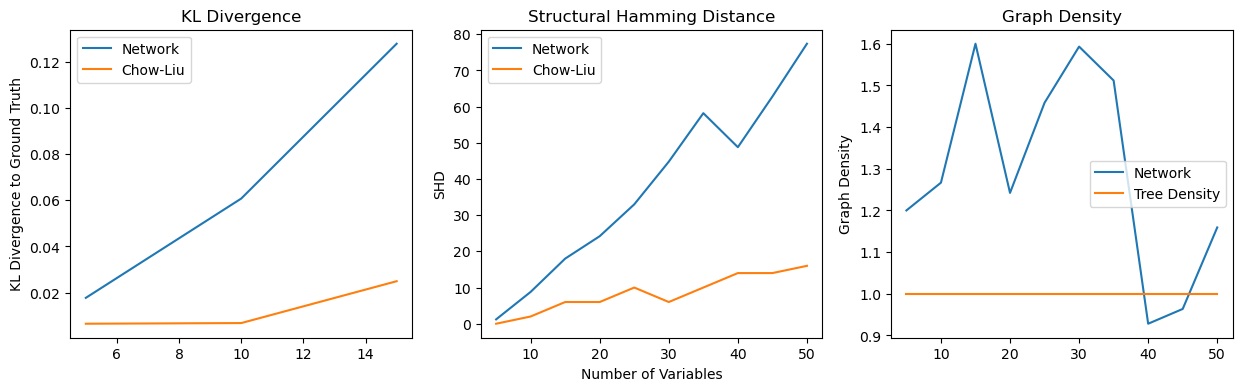

In [25]:
# Tree with varying size

fig, axs = plt.subplots(1,3,figsize=(15,4))

plot_metric(results_trees, 'n_variables', 'KL', axs[0], label="Network")
plot_metric(results_trees, 'n_variables', 'KL Chow-Liu', axs[0], label="Chow-Liu")

plot_metric(results_trees, 'n_variables', 'SHD', axs[1], label="Network")
plot_metric(results_trees, 'n_variables', 'SHD Chow-Liu', axs[1], label="Chow-Liu")

plot_metric(results_trees, 'n_variables', 'density', axs[2], label="Network")
plot_metric(results_trees, 'n_variables', 'true density', axs[2], label="Tree Density")


axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_title("KL Divergence")
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Number of Variables")
axs[1].set_title("Structural Hamming Distance")
axs[1].legend()

axs[2].set_ylabel("Graph Density")
axs[2].set_title("Graph Density")
axs[2].legend()

# plt.savefig('../img/comp_tree.png')
plt.show()


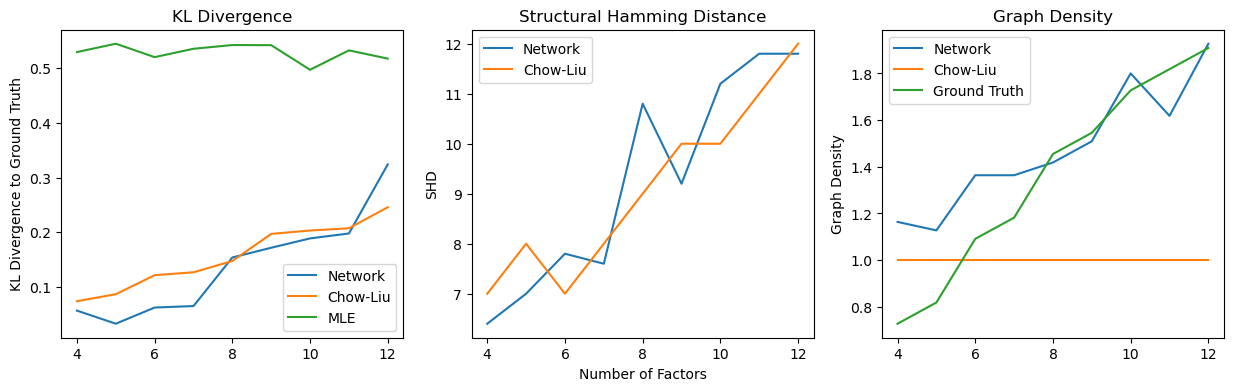

In [26]:
# Graph with varying density

fig, axs = plt.subplots(1,3,figsize=(15,4))

plot_metric(results_graphs, 'n_factors', 'KL', axs[0], label="Network")
plot_metric(results_graphs, 'n_factors', 'KL Chow-Liu', axs[0], label="Chow-Liu")
plot_metric(results_graphs, 'n_factors', 'KL MLE', axs[0], label="MLE")

plot_metric(results_graphs, 'n_factors', 'SHD', axs[1], label="Network")
plot_metric(results_graphs, 'n_factors', 'SHD Chow-Liu', axs[1], label="Chow-Liu")

plot_metric(results_graphs, 'n_factors', 'density', axs[2], label="Network")
axs[2].plot(extract_metric(results_graphs, 'n_factors'), [1 for _ in range(len(results_graphs))], label = "Chow-Liu")
plot_metric(results_graphs, 'n_factors', 'true density', axs[2], label="Ground Truth")


axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_title("KL Divergence")
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Number of Factors")
axs[1].set_title("Structural Hamming Distance")
axs[1].legend()

axs[2].set_ylabel("Graph Density")
axs[2].set_title("Graph Density")
axs[2].legend()

# plt.savefig('../img/comp_graph.png')
plt.show()

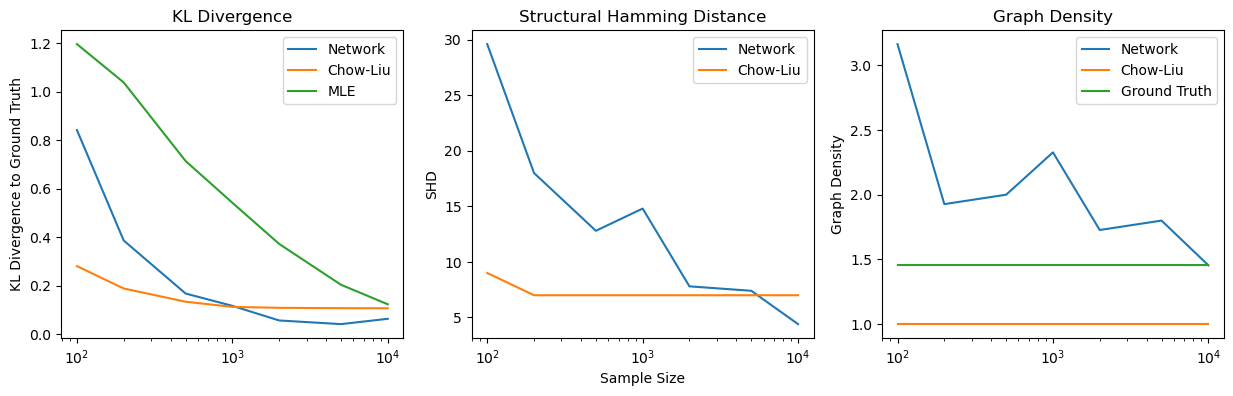

In [27]:
# Fixed graph with varying sample size

fig, axs = plt.subplots(1,3,figsize=(15,4))

plot_metric(results_samples, 'n_samples', 'KL', axs[0], label="Network")
plot_metric(results_samples, 'n_samples', 'KL Chow-Liu', axs[0], label="Chow-Liu")
plot_metric(results_samples, 'n_samples', 'KL MLE', axs[0], label="MLE")

plot_metric(results_samples, 'n_samples', 'SHD', axs[1], label="Network")
plot_metric(results_samples, 'n_samples', 'SHD Chow-Liu', axs[1], label="Chow-Liu")

plot_metric(results_samples, 'n_samples', 'density', axs[2], label="Network")
axs[2].plot(extract_metric(results_samples, 'n_samples'), [1 for _ in range(len(results_samples))], label = "Chow-Liu")
plot_metric(results_samples, 'n_samples', 'true density', axs[2], label="Ground Truth")

axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_title("KL Divergence")
axs[0].set_xscale('log')
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Sample Size")
axs[1].set_title("Structural Hamming Distance")
axs[1].set_xscale('log')
axs[1].legend()

axs[2].set_ylabel("Graph Density")
axs[2].set_title("Graph Density")
axs[2].set_xscale('log')
axs[2].legend()

# plt.savefig('../img/comp_samples.png')
plt.show()

# Final Visualizations (without density)

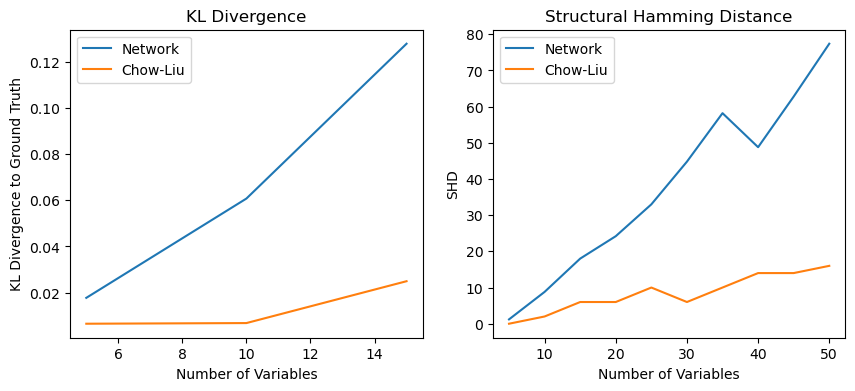

In [35]:
# Tree with varying size

fig, axs = plt.subplots(1,2,figsize=(10,4))

plot_metric(results_trees, 'n_variables', 'KL', axs[0], label="Network")
plot_metric(results_trees, 'n_variables', 'KL Chow-Liu', axs[0], label="Chow-Liu")

plot_metric(results_trees, 'n_variables', 'SHD', axs[1], label="Network")
plot_metric(results_trees, 'n_variables', 'SHD Chow-Liu', axs[1], label="Chow-Liu")


axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_xlabel("Number of Variables")
axs[0].set_title("KL Divergence")
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Number of Variables")
axs[1].set_title("Structural Hamming Distance")
axs[1].legend()

# plt.savefig('../img/comp_tree.png')
plt.show()


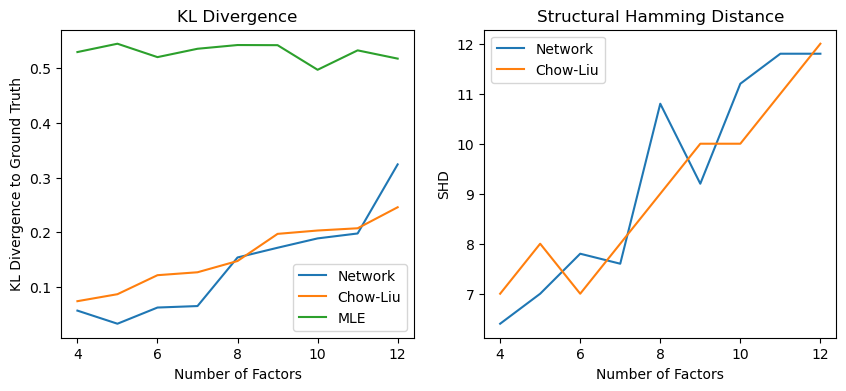

In [37]:
# Graph with varying density

fig, axs = plt.subplots(1,2,figsize=(10,4))

plot_metric(results_graphs, 'n_factors', 'KL', axs[0], label="Network")
plot_metric(results_graphs, 'n_factors', 'KL Chow-Liu', axs[0], label="Chow-Liu")
plot_metric(results_graphs, 'n_factors', 'KL MLE', axs[0], label="MLE")

plot_metric(results_graphs, 'n_factors', 'SHD', axs[1], label="Network")
plot_metric(results_graphs, 'n_factors', 'SHD Chow-Liu', axs[1], label="Chow-Liu")


axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_xlabel("Number of Factors")
axs[0].set_title("KL Divergence")
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Number of Factors")
axs[1].set_title("Structural Hamming Distance")
axs[1].legend()

# plt.savefig('../img/comp_graph.png')
plt.show()

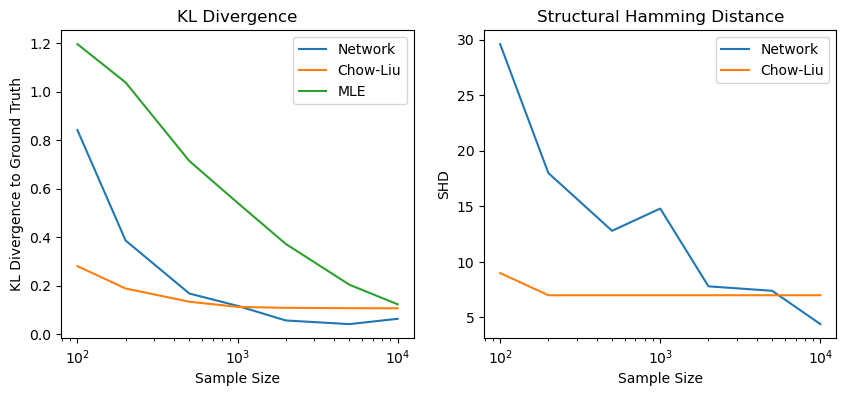

In [39]:
# Fixed graph with varying sample size

fig, axs = plt.subplots(1,2,figsize=(10,4))

plot_metric(results_samples, 'n_samples', 'KL', axs[0], label="Network")
plot_metric(results_samples, 'n_samples', 'KL Chow-Liu', axs[0], label="Chow-Liu")
plot_metric(results_samples, 'n_samples', 'KL MLE', axs[0], label="MLE")

plot_metric(results_samples, 'n_samples', 'SHD', axs[1], label="Network")
plot_metric(results_samples, 'n_samples', 'SHD Chow-Liu', axs[1], label="Chow-Liu")

axs[0].set_ylabel("KL Divergence to Ground Truth")
axs[0].set_xlabel("Sample Size")
axs[0].set_title("KL Divergence")
axs[0].set_xscale('log')
axs[0].legend()

axs[1].set_ylabel("SHD")
axs[1].set_xlabel("Sample Size")
axs[1].set_title("Structural Hamming Distance")
axs[1].set_xscale('log')
axs[1].legend()

# plt.savefig('../img/comp_samples.png')
plt.show()

# Data for Tables

In [28]:
# Graph Size
for r in results_trees:
    print(f"\nNumber Variables = {r['n_variables']}, Number Factors = {r['n_factors']}, Number Samples = {r['n_samples']}--------")
    if r['KL']['mean'] is not None:
        print(f"\tKL Network: {r['KL']['mean']:.2f}+-{r['KL']['sd']:.2f}\tKL Chow-Liu: {r['KL Chow-Liu']:.2f}\tKL MLE: {r['KL MLE']:.2f}")
    else:
        print(f"\tKL Network: --\tKL Chow-Liu: --\tKL MLE: --")        
    print(f"\tSHD: {r['SHD']['mean']:.1f}+-{r['SHD']['sd']:.1f}\tSHD Chow-Liu: {r['SHD Chow-Liu']}")


Number Variables = 5, Number Factors = 4, Number Samples = 1000--------
	KL Network: 0.02+-0.00	KL Chow-Liu: 0.01	KL MLE: 0.02
	SHD: 1.2+-0.7	SHD Chow-Liu: 0

Number Variables = 10, Number Factors = 9, Number Samples = 1000--------
	KL Network: 0.06+-0.05	KL Chow-Liu: 0.01	KL MLE: 0.27
	SHD: 8.8+-1.7	SHD Chow-Liu: 2

Number Variables = 15, Number Factors = 14, Number Samples = 1000--------
	KL Network: 0.13+-0.07	KL Chow-Liu: 0.02	KL MLE: 1.38
	SHD: 18.0+-2.1	SHD Chow-Liu: 6

Number Variables = 20, Number Factors = 19, Number Samples = 1000--------
	KL Network: --	KL Chow-Liu: --	KL MLE: --
	SHD: 24.2+-3.5	SHD Chow-Liu: 6

Number Variables = 25, Number Factors = 24, Number Samples = 1000--------
	KL Network: --	KL Chow-Liu: --	KL MLE: --
	SHD: 33.0+-4.6	SHD Chow-Liu: 10

Number Variables = 30, Number Factors = 29, Number Samples = 1000--------
	KL Network: --	KL Chow-Liu: --	KL MLE: --
	SHD: 44.8+-5.3	SHD Chow-Liu: 6

Number Variables = 35, Number Factors = 34, Number Samples = 1000--

In [29]:
# Graph Density
for r in results_graphs:
    print(f"\nNumber Variables = {r['n_variables']}, Number Factors = {r['n_factors']}, Number Samples = {r['n_samples']}--------")
    if r['KL']['mean'] is not None:
        print(f"\tKL Network: {r['KL']['mean']:.2f}+-{r['KL']['sd']:.2f}\tKL Chow-Liu: {r['KL Chow-Liu']:.2f}\tKL MLE: {r['KL MLE']:.2f}")
    else:
        print(f"\tKL Network: --\tKL Chow-Liu: --\tKL MLE: --")        
    print(f"\tSHD: {r['SHD']['mean']:.1f}+-{r['SHD']['sd']:.1f}\tSHD Chow-Liu: {r['SHD Chow-Liu']}")


Number Variables = 12, Number Factors = 4, Number Samples = 1000--------
	KL Network: 0.06+-0.04	KL Chow-Liu: 0.07	KL MLE: 0.53
	SHD: 6.4+-2.7	SHD Chow-Liu: 7

Number Variables = 12, Number Factors = 5, Number Samples = 1000--------
	KL Network: 0.03+-0.01	KL Chow-Liu: 0.09	KL MLE: 0.54
	SHD: 7.0+-1.4	SHD Chow-Liu: 8

Number Variables = 12, Number Factors = 6, Number Samples = 1000--------
	KL Network: 0.06+-0.03	KL Chow-Liu: 0.12	KL MLE: 0.52
	SHD: 7.8+-1.8	SHD Chow-Liu: 7

Number Variables = 12, Number Factors = 7, Number Samples = 1000--------
	KL Network: 0.07+-0.03	KL Chow-Liu: 0.13	KL MLE: 0.54
	SHD: 7.6+-2.1	SHD Chow-Liu: 8

Number Variables = 12, Number Factors = 8, Number Samples = 1000--------
	KL Network: 0.15+-0.05	KL Chow-Liu: 0.15	KL MLE: 0.54
	SHD: 10.8+-1.7	SHD Chow-Liu: 9

Number Variables = 12, Number Factors = 9, Number Samples = 1000--------
	KL Network: 0.17+-0.07	KL Chow-Liu: 0.20	KL MLE: 0.54
	SHD: 9.2+-1.2	SHD Chow-Liu: 10

Number Variables = 12, Number Factors

In [30]:
# Sample Size
for r in results_samples:
    print(f"\nNumber Variables = {r['n_variables']}, Number Factors = {r['n_factors']}, Number Samples = {r['n_samples']}--------")
    if r['KL']['mean'] is not None:
        print(f"\tKL Network: {r['KL']['mean']:.2f}+-{r['KL']['sd']:.2f}\tKL Chow-Liu: {r['KL Chow-Liu']:.2f}\tKL MLE: {r['KL MLE']:.2f}")
    else:
        print(f"\tKL Network: --\tKL Chow-Liu: --\tKL MLE: --")        
    print(f"\tSHD: {r['SHD']['mean']:.1f}+-{r['SHD']['sd']:.1f}\tSHD Chow-Liu: {r['SHD Chow-Liu']}")


Number Variables = 12, Number Factors = 10, Number Samples = 100--------
	KL Network: 0.84+-0.09	KL Chow-Liu: 0.28	KL MLE: 1.20
	SHD: 29.6+-4.8	SHD Chow-Liu: 9

Number Variables = 12, Number Factors = 10, Number Samples = 200--------
	KL Network: 0.39+-0.08	KL Chow-Liu: 0.19	KL MLE: 1.04
	SHD: 18.0+-4.6	SHD Chow-Liu: 7

Number Variables = 12, Number Factors = 10, Number Samples = 500--------
	KL Network: 0.17+-0.04	KL Chow-Liu: 0.13	KL MLE: 0.71
	SHD: 12.8+-2.6	SHD Chow-Liu: 7

Number Variables = 12, Number Factors = 10, Number Samples = 1000--------
	KL Network: 0.12+-0.05	KL Chow-Liu: 0.11	KL MLE: 0.54
	SHD: 14.8+-3.9	SHD Chow-Liu: 7

Number Variables = 12, Number Factors = 10, Number Samples = 2000--------
	KL Network: 0.06+-0.02	KL Chow-Liu: 0.11	KL MLE: 0.37
	SHD: 7.8+-3.2	SHD Chow-Liu: 7

Number Variables = 12, Number Factors = 10, Number Samples = 5000--------
	KL Network: 0.04+-0.01	KL Chow-Liu: 0.11	KL MLE: 0.20
	SHD: 7.4+-4.3	SHD Chow-Liu: 7

Number Variables = 12, Number Fa

# Show Graphs

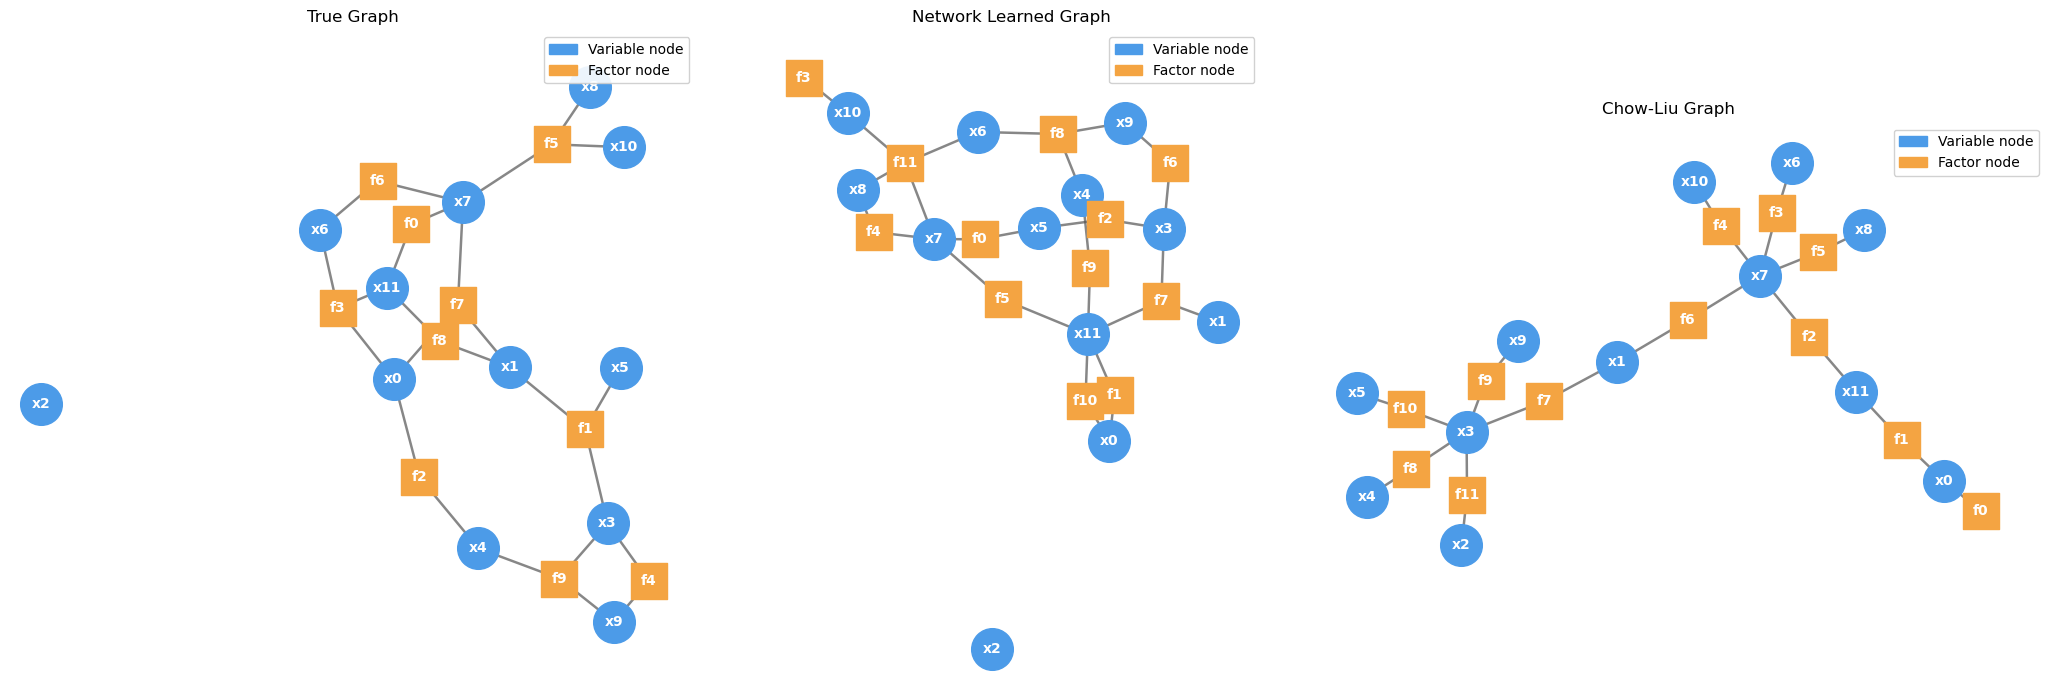

In [100]:
EXAMPLE = 6
res = results_graphs[EXAMPLE]

# show_graphs(results_graphs[6], seed_true=2, seed_lrn=16, seed_cl=6, size=7, savefig=True, path="../img/comp_ex.png")
show_graphs(res, seed_true=2, seed_lrn=16, seed_cl=6, size=7)

In [93]:
compare_graph(res['True Graph'], res['learners'][0])

=== GRAPH 1 FACTORS ===
[7, 11]
[1, 3, 5]
[0, 4]
[0, 6, 11]
[3, 9]
[7, 8, 10]
[6, 7]
[0, 1, 7]
[1, 11]
[3, 4, 9]

=== GRAPH 2 FACTORS ===
[5, 7]
[0, 11]
[3, 4, 5]
[10]
[7, 8]
[7, 11]
[3, 9]
[1, 3, 11]
[4, 6, 9]
[4, 11]
[0, 11]
[6, 7, 8, 10]


In [94]:
compare_graph(res['True Graph'], res['Chow-Liu Graph'])

=== GRAPH 1 FACTORS ===
[7, 11]
[1, 3, 5]
[0, 4]
[0, 6, 11]
[3, 9]
[7, 8, 10]
[6, 7]
[0, 1, 7]
[1, 11]
[3, 4, 9]

=== GRAPH 2 FACTORS ===
[0]
[0, 11]
[7, 11]
[6, 7]
[7, 10]
[7, 8]
[1, 7]
[1, 3]
[3, 4]
[3, 9]
[3, 5]
[2, 3]


In [95]:
factor_metrics(res['True Graph'], res['learners'][0])

{'precision': 0.18181818165289254,
 'recall': 0.1999999998,
 'tp': 2,
 'fp': 9,
 'fn': 8}

In [96]:
factor_metrics(res['True Graph'], res['Chow-Liu Graph'])

{'precision': 0.24999999979166665,
 'recall': 0.29999999969999996,
 'tp': 3,
 'fp': 9,
 'fn': 7}

In [97]:
edge_metrics(res['True Graph'], res['learners'][0])

{'precision': 0.5999999997,
 'recall': 0.631578947036011,
 'tp': 12,
 'fp': 8,
 'fn': 7}

In [98]:
edge_metrics(res['True Graph'], res['Chow-Liu Graph'])

{'precision': 0.9090909082644627,
 'recall': 0.5263157891966759,
 'tp': 10,
 'fp': 1,
 'fn': 9}